# Install Modules, Libraries, Packages

In [141]:
# Data analysis tools
import pandas as pd
import numpy as np

# For timing models
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train and Testing Split
from sklearn.model_selection import train_test_split

# Classification Models
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree

# Classification Metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Regression Models
from sklearn.linear_model import LinearRegression

# Regression Metrics
from sklearn.metrics import r2_score, mean_squared_error

# Dimension Reduction
from sklearn.decomposition import PCA, KernelPCA as KPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Standardization
from sklearn.preprocessing import StandardScaler

# Functions

In [142]:
def print_info(df):
    """Prints number of rows, columns, and missing values in a dataset"""
    print(f"The dataset has:\n{df.shape[0]} rows\n{df.shape[1]} columns")
    print(f"The dataset has a total of {df.isna().sum().sum()} missing values")
    print(f"The missing values per column are:\n{df.isna().sum()}")

def clean_dataset(df):
    """Removes any missing values in a dataset"""
    if df.isna().any().any():
        #remove missing values
        df = df.dropna()

        #recalculate column and row number
        print(f"Number of rows in dataset after removing missing values: {df.shape[0]}")
        print(f"Number of columns in dataset after removing missing values: {df.shape[1]}")
    
    else:
        print("The dataset has no missing values.")
    
    return df

def standardize_data(X_train, X_test):
    """Standerdizes feature X training data and testing"""
    
    # Intialize StandardScaler
    std = StandardScaler()

    # Fit and transform the scaler to X_train and X, test
    X_train_std = std.fit_transform(X_train)
    X_test_std = std.transform(X_test)

    return X_train_std, X_test_std

# I want to create a function that will perform PCA, LDA, or KPCA if the user defines it
def dim_reduce(technique, X_train_std, X_test_std, y=None, **kwargs):
    """User defines preprocessing technique to perform on dataset"""
    
    # Check to see if the technique
    technique = technique.strip().lower()

    # establish dictionary of dimension reduction techniques
    dim_red = {"pca": PCA, 
               "lda": LDA, 
               "kpca": KPCA
               }
    
    # Check is technique
    if technique not in dim_red:
        raise ValueError(f"Invalid technique name.Please choose from {list(dim_red.keys())}")
    else:
        pass
    
    # Record start time
    start_time = time.time()
    
    # Intialize Technique
    t = dim_red[technique](**kwargs)

    # Call Technique on standerdized X and y (if appropriate)
    if technique == "lda":
        X_train_std_t = t.fit_transform(X_train_std,y)
        X_test_std_t = t.transform(X_test_std)
    
    else:
        X_train_std_t = t.fit_transform(X_train_std)
        X_test_std_t = t.transform(X_test_std)

    # Record Stop time
    stop_time = time.time() - start_time

    # Print Time
    print(f"Dimension Reduction Technique time: {stop_time:.4f} seconds")

    return t, X_train_std_t, X_test_std_t

def print_reg_metrics(y_test,y_pred):
    """Prints Metrics of a Regression Model.
       Returns error and R2 score."""
    # Store metrics in
    mse   = mean_squared_error(y_test, y_pred)
    reg_score = r2_score(y_test, y_pred)

    reg_metrics = {"mse": mse , 
               "R2 score": reg_score}

    # Print the misclassified examples and error
    print("Mean Squared Error: %.3f" % (mse))
    
    # Print regression r2_score
    print("R² score:", reg_score)

    # Return metrics
    return reg_metrics

def print_class_metrics(y_test,y_pred):
    """Prints Metrics of a classification Model.
       Returns confusion matrix, accuracy, precision, recall, and f1_score"""
    # Store metrics
    c_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    class_metrics = {"confusion_matrix": c_matrix, 
                     "accuracy": accuracy,
                     "precision": precision, 
                     "recall": recall, 
                     "f1": f1}
    # Print the misclassified examples and error
    print(f"Misclassifed examples: {(y_test != y_pred).sum()} out of {y_test.shape[0]}")
    print("Error: %.3f" % (((y_test != y_pred).sum())/(y_test.shape[0])))
    
    # Print classifier confusion matrix, accuracy, precision, and recall
    print(f"Confusion_Matrix:\n{c_matrix}")
    print("Accuracy: %.3f" % accuracy)
    print("Precision %.3f" % precision)
    print("Recall: %.3f" % recall)
    print("F1_score: %.3f" % f1)

    return class_metrics

def get_model(name):
    classifiers = {"perceptron": Perceptron,
                   "decisiontree":DecisionTreeClassifier,
                   "logisticregression":LogisticRegression,
                   "knn":KNeighborsClassifier,
                   "linearsvm": SVC,
                   "nonlinearsvm": SVC,
                   "linearregression":LinearRegression
                   }

    name = name.lower().strip().replace(" ", "") #to allow for accidental uppercase letter like Perceptron

    if name not in classifiers:
        raise ValueError(f"Invalid classifier name.Please choose from {list(classifiers.keys())}")

    return classifiers[name]
    
def classification_model(model_name,X_train_std, X_test_std, y_train, y_test, **kwargs):
    """Initalizes, Fits, and Predicts using a Classification Model"""

    #Choose classifier
    clf_class = get_model(model_name)

    # intitialize the model
    model = clf_class(**kwargs)

    # Get start time of training model
    train_start = time.time()

    # Fit the model 
    model.fit(X_train_std, y_train)

    # Stop the timer
    train_time = time.time() - train_start

    # Print training time
    print(f"Training time: {train_time:.4f} seconds")

    # Get start time of testing model
    test_start = time.time()

    # Predict the overall class, ie predicted hand number
    y_pred = model.predict(X_test_std)

    # Stop the timer
    test_time = time.time() - test_start

    # Print testing time
    print(f"Testing time: {test_time:.4f} seconds")

    # Print Metrics
    print_class_metrics(y_test, y_pred)
    
    # Return model
    return model

def regression_model(model_name,X_train_std, X_test_std, y_train, y_test, **kwargs):
    """Initalizes, Fits, and Predicts using a Regression Model"""
    #Choose classifier
    reg_model = get_model(model_name)

    # intitialize the model
    model = reg_model(**kwargs)

    # Get start time of training model
    train_start = time.time()

    # Fit the model 
    model.fit(X_train_std, y_train)

    # Stop the timer
    train_time = time.time() - train_start

    # Print training time
    print(f"Training time: {train_time:.4f} seconds")

    # Get start time of testing model
    test_start = time.time()

    # Predict the overall class, ie predicted hand number
    y_pred = model.predict(X_test_std)

    # Stop the timer
    test_time = time.time() - test_start

    # Print testing time
    print(f"Testing time: {test_time:.4f} seconds")

    # Print Metrics
    print_reg_metrics(y_test, y_pred)

    # Return model
    return model

# Load Datasets

In [143]:
# Load Census Data
county_census_data = pd.read_csv("../DATA/PROCESSED_CENSUS_DATA/county_census_data_2024.csv", index_col=0)

# Print Info
print_info(county_census_data)

# Clean Data
clean_dataset(county_census_data)

# View
county_census_data.head(20)

The dataset has:
850 rows
53 columns
The dataset has a total of 0 missing values
The missing values per column are:
state                                                                       0
county                                                                      0
Less than $10,000                                                           0
$10,000 to $14,999                                                          0
$15,000 to $24,999                                                          0
$25,000 to $34,999                                                          0
$35,000 to $49,999                                                          0
$50,000 to $74,999                                                          0
$75,000 to $99,999                                                          0
$100,000 to $149,999                                                        0
$150,000 to $199,999                                                        0
$200,000 or more          

,state,county,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999",...,35 to 44 years,45 to 54 years,55 to 59 years,60 to 64 years,65 to 74 years,75 to 84 years,85 years and over,Female,Male,Total population
0,Idaho,Ada County,0.037,0.030,0.042,0.044,0.086,0.154,0.146,0.204,...,0.144,0.128,0.054,0.061,0.103,0.054,0.018,0.497,0.503,535799.0
1,Colorado,Adams County,0.034,0.022,0.041,0.046,0.073,0.144,0.126,0.226,...,0.158,0.123,0.047,0.055,0.074,0.035,0.010,0.491,0.509,542973.0
2,Pennsylvania,Adams County,0.029,0.013,0.052,0.081,0.096,0.168,0.135,0.210,...,0.111,0.115,0.070,0.072,0.142,0.069,0.023,0.501,0.499,107914.0
3,South Carolina,Aiken County,0.067,0.030,0.051,0.088,0.127,0.157,0.150,0.152,...,0.129,0.112,0.059,0.073,0.126,0.076,0.015,0.513,0.487,179245.0
4,Florida,Alachua County,0.093,0.058,0.088,0.070,0.083,0.165,0.141,0.130,...,0.130,0.092,0.041,0.052,0.095,0.049,0.017,0.523,0.477,291782.0
5,North Carolina,Alamance County,0.043,0.037,0.075,0.068,0.130,0.204,0.129,0.166,...,0.123,0.120,0.069,0.061,0.100,0.058,0.015,0.516,0.484,183040.0
6,California,Alameda County,0.041,0.030,0.047,0.034,0.061,0.102,0.093,0.157,...,0.161,0.133,0.062,0.058,0.094,0.051,0.020,0.503,0.497,1649060.0
7,New York,Albany County,0.057,0.033,0.056,0.053,0.090,0.176,0.124,0.167,...,0.124,0.112,0.061,0.060,0.106,0.061,0.023,0.513,0.487,319964.0
8,Virginia,Albemarle County,0.041,0.016,0.031,0.034,0.071,0.163,0.134,0.171,...,0.131,0.104,0.047,0.068,0.118,0.061,0.037,0.522,0.478,117313.0
9,Virginia,Alexandria city,0.033,0.010,0.038,0.027,0.042,0.130,0.104,0.206,...,0.194,0.122,0.064,0.047,0.080,0.041,0.014,0.506,0.494,159102.0


In [144]:
county_census_data["county"].unique()

array(['Ada County', 'Adams County', 'Aiken County', 'Alachua County',
       'Alamance County', 'Alameda County', 'Albany County',
       'Albemarle County', 'Alexandria city', 'Allegan County',
       'Allegany County', 'Allegheny County', 'Allen County',
       'Anchorage Municipality', 'Anderson County', 'Androscoggin County',
       'Angelina County', 'Anne Arundel County', 'Anoka County',
       'Apache County', 'Arapahoe County', 'Arlington County',
       'Armstrong County', 'Aroostook County', 'Ascension Parish',
       'Ashtabula County', 'Atlantic County', 'Augusta County',
       'Baldwin County', 'Baltimore County', 'Baltimore city',
       'Bannock County', 'Barnstable County', 'Barrow County',
       'Bartholomew County', 'Bartow County', 'Bastrop County',
       'Bay County', 'Beaufort County', 'Beaver County', 'Bedford County',
       'Belknap County', 'Bell County', 'Belmont County', 'Benton County',
       'Bergen County', 'Berkeley County', 'Berks County',
       'B

In [145]:
# Load Crime Data
county_crime_data = pd.read_csv("../DATA/PROCESSED_CRIME_DATA/county_crime_data_2024.csv")

# Print Info
print_info(county_crime_data)

# Clean Data
clean_dataset(county_crime_data)

# View
county_crime_data.head(20)

The dataset has:
3521 rows
12 columns
The dataset has a total of 0 missing values
The missing values per column are:
state_abbr              0
state_name              0
county_name             0
latitude                0
longitude               0
Population_2024         0
Arrests_2024            0
Violent_Crimes_2024     0
Property_Crimes_2024    0
Arrest_Rate             0
Violent_Crime_Rate      0
Property_Crime_Rate     0
dtype: int64
The dataset has no missing values.


,state_abbr,state_name,county_name,latitude,longitude,Population_2024,Arrests_2024,Violent_Crimes_2024,Property_Crimes_2024,Arrest_Rate,Violent_Crime_Rate,Property_Crime_Rate
0,AK,Alaska,ALEUTIANS WEST,51.959447,-178.338813,4204.0,42,6,4.0,999.048525,142.721218,95.147479
1,AK,Alaska,BETHEL,60.928916,-160.153350,6280.0,748,104,145.0,11910.828025,1656.050955,2308.917197
2,AK,Alaska,BRISTOL BAY,58.732389,-156.986661,856.0,28,7,6.0,3271.028037,817.757009,700.934579
3,AK,Alaska,DILLINGHAM,59.824816,-158.602233,2088.0,35,7,1.0,1676.245211,335.249042,47.892720
4,AK,Alaska,FAIRBANKS NORTH STAR,64.797240,-147.535115,34166.0,1052,237,1157.0,3079.084470,693.672072,3386.407540
5,AK,Alaska,HAINES,59.098771,-135.576936,2083.0,15,6,8.0,720.115218,288.046087,384.061450
6,AK,Alaska,JUNEAU,58.356556,-134.507310,31612.0,794,163,668.0,2511.704416,515.626977,2113.121599
7,AK,Alaska,KENAI PENINSULA,60.264119,-151.543888,21451.0,913,42,258.0,4256.211832,195.795068,1202.741131
8,AK,Alaska,KETCHIKAN GATEWAY,55.449938,-131.106685,8050.0,113,32,175.0,1403.726708,397.515528,2173.913043
9,AK,Alaska,KODIAK ISLAND,57.804900,-152.373320,5289.0,153,14,54.0,2892.796370,264.700321,1020.986954


# Text Cleaning in County Column

In [146]:
def clean_text(column):
    column = column.astype(str)
    # standardize case + whitespace
    column = column.str.lower().str.strip()

    # saint → st. (only at start)
    column = column.str.replace(r"^saint\s+", "st ", regex=True)

    # st → st. (ONLY as a standalone word)
    column = column.str.replace(r"\bst\b", "st", regex=True)

    # remove county
    column = column.str.replace(" county", "", regex=False)

    # normalize spacing
    column = column.str.replace(r"\s+", " ", regex=True)

    return column

In [147]:
county_census_data["county"] = clean_text(column=county_census_data["county"])
county_crime_data["county_name"] = clean_text(column=county_crime_data["county_name"])

# Combine Datasets

In [148]:
# Sub Data
total_crime = county_crime_data[["state_name","county_name","latitude","longitude","Violent_Crimes_2024", "Property_Crimes_2024"]]

# Change State to state
total_crime = total_crime.rename(columns={"state_name":"state"})
total_crime = total_crime.rename(columns={"county_name":"county"})

# Lower All State Names in both dataset
county_census_data['state'] = county_census_data["state"].str.lower()
county_census_data['county'] = county_census_data["county"].str.lower()

total_crime["state"] = total_crime["state"].str.lower()
total_crime["county"] = total_crime["county"].str.lower()

# Create a copy
census_df = county_census_data.copy()

# Combine
crime_census_df = pd.merge(census_df, total_crime, on=["county","state"], how="left")

# Rename a column 
crime_census_df.rename(columns={'Total': 'Total Households'}, inplace=True)

# Calculate Crime Rate and Violent Crime Rate
crime_census_df["Total_Crime"] = crime_census_df['Property_Crimes_2024'] + crime_census_df['Violent_Crimes_2024']
crime_census_df['Total_Crime_Rate'] = crime_census_df['Total_Crime'] / crime_census_df['Total population'] * 100000
crime_census_df['Property_Crime_Rate'] = crime_census_df['Property_Crimes_2024'] / crime_census_df['Total population'] * 100000
crime_census_df['Violent_Crime_Rate'] = crime_census_df['Violent_Crimes_2024'] / crime_census_df['Total population'] * 100000

# Print Info
print_info(crime_census_df)

# View
crime_census_df

The dataset has:
850 rows
61 columns
The dataset has a total of 408 missing values
The missing values per column are:
state                    0
county                   0
Less than $10,000        0
$10,000 to $14,999       0
$15,000 to $24,999       0
                        ..
Property_Crimes_2024    51
Total_Crime             51
Total_Crime_Rate        51
Property_Crime_Rate     51
Violent_Crime_Rate      51
Length: 61, dtype: int64


,state,county,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999",...,Male,Total population,latitude,longitude,Violent_Crimes_2024,Property_Crimes_2024,Total_Crime,Total_Crime_Rate,Property_Crime_Rate,Violent_Crime_Rate
0,idaho,ada,0.037,0.030,0.042,0.044,0.086,0.154,0.146,0.204,...,0.503,535799.0,43.577170,-116.261839,1224.0,4222.0,5446.0,1016.425936,787.982060,228.443875
1,colorado,adams,0.034,0.022,0.041,0.046,0.073,0.144,0.126,0.226,...,0.509,542973.0,39.824275,-104.598730,1482.0,8849.0,10331.0,1902.672877,1629.731128,272.941748
2,pennsylvania,adams,0.029,0.013,0.052,0.081,0.096,0.168,0.135,0.210,...,0.499,107914.0,39.855277,-77.259168,45.0,269.0,314.0,290.972441,249.272569,41.699872
3,south carolina,aiken,0.067,0.030,0.051,0.088,0.127,0.157,0.150,0.152,...,0.487,179245.0,33.585875,-81.604598,501.0,3513.0,4014.0,2239.393010,1959.887305,279.505704
4,florida,alachua,0.093,0.058,0.088,0.070,0.083,0.165,0.141,0.130,...,0.477,291782.0,29.667708,-82.340616,1353.0,5677.0,7030.0,2409.332995,1945.630642,463.702353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,pennsylvania,york,0.035,0.020,0.057,0.070,0.110,0.167,0.132,0.206,...,0.498,471240.0,39.805897,-76.825355,72.0,0.0,72.0,15.278839,0.000000,15.278839
846,south carolina,york,0.031,0.013,0.049,0.045,0.083,0.159,0.145,0.206,...,0.487,303001.0,34.881805,-81.129638,781.0,4114.0,4895.0,1615.506219,1357.751295,257.754925
847,virginia,york,0.030,0.003,0.019,0.067,0.060,0.138,0.142,0.197,...,0.512,71410.0,37.220914,-76.395533,138.0,950.0,1088.0,1523.596135,1330.345890,193.250245
848,california,yuba,0.023,0.021,0.054,0.078,0.110,0.186,0.127,0.165,...,0.507,87469.0,38.902210,-121.570638,462.0,785.0,1247.0,1425.647944,897.460815,528.187129


 View the Rows from the county_census_data that didn't have a match. 

In [149]:
crime_census_df[crime_census_df.isna().any(axis=1)]

,state,county,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999",...,Male,Total population,latitude,longitude,Violent_Crimes_2024,Property_Crimes_2024,Total_Crime,Total_Crime_Rate,Property_Crime_Rate,Violent_Crime_Rate
15,alaska,anchorage municipality,0.032,0.013,0.055,0.045,0.078,0.119,0.121,0.215,...,0.508,289600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,louisiana,ascension parish,0.032,0.016,0.041,0.052,0.077,0.157,0.139,0.179,...,0.484,133534.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,louisiana,bossier parish,0.064,0.041,0.066,0.086,0.114,0.192,0.108,0.183,...,0.488,131102.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,new york,bronx,0.130,0.088,0.104,0.091,0.116,0.148,0.102,0.116,...,0.472,1384724.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,louisiana,caddo parish,0.087,0.077,0.101,0.090,0.117,0.172,0.109,0.147,...,0.471,224893.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,louisiana,calcasieu parish,0.069,0.053,0.076,0.075,0.113,0.164,0.129,0.149,...,0.490,206861.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161,new york,clinton,0.046,0.025,0.071,0.072,0.155,0.168,0.123,0.222,...,0.516,77871.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210,district of columbia,district of columbia,0.078,0.035,0.057,0.039,0.053,0.105,0.098,0.168,...,0.473,702250.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219,new mexico,doña ana,0.059,0.053,0.103,0.088,0.109,0.174,0.118,0.158,...,0.486,229366.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225,louisiana,east baton rouge parish,0.114,0.053,0.084,0.060,0.099,0.157,0.123,0.150,...,0.478,453022.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


drop the NAs

In [150]:
crime_census_df = crime_census_df.dropna()

print_info(crime_census_df)

The dataset has:
799 rows
61 columns
The dataset has a total of 0 missing values
The missing values per column are:
state                   0
county                  0
Less than $10,000       0
$10,000 to $14,999      0
$15,000 to $24,999      0
                       ..
Property_Crimes_2024    0
Total_Crime             0
Total_Crime_Rate        0
Property_Crime_Rate     0
Violent_Crime_Rate      0
Length: 61, dtype: int64


# Regression Models

## Linear Regression

In [ ]:
#Create a copy 
df = crime_census_df.copy()

# Convert to totals, linear regression performs poorly with a crime rate and percentages

# Identify columns related to income
income_cols = ['Less than $10,000', '$10,000 to $14,999','$15,000 to $24,999', '$25,000 to $34,999', '$35,000 to $49,999',
               '$50,000 to $74,999', '$75,000 to $99,999', '$100,000 to $149,999',
               '$150,000 to $199,999', '$200,000 or more']

# Identify columns related to education
education_cols = ["population_18_to_24_years_bachelor's_degree_or_higher",
       "population_18_to_24_years_high_school_graduate_(includes_equivalency)",
       "population_18_to_24_years_less_than_high_school_graduate",
       "population_18_to_24_years_some_college_or_associate's_degree",
       "population_25_to_34_years_bachelor's_degree_or_higher",
       "population_25_to_34_years_high_school_graduate_or_higher",
       "population_25_years_and_over_9th_to_12th_grade,_no_diploma",
       "population_25_years_and_over_associate's_degree",
       "population_25_years_and_over_bachelor's_degree",
       "population_25_years_and_over_bachelor's_degree_or_higher",
       "population_25_years_and_over_graduate_or_professional_degree",
       'population_25_years_and_over_high_school_graduate_(includes_equivalency)',
       'population_25_years_and_over_high_school_graduate_or_higher',
       'population_25_years_and_over_less_than_9th_grade',
       'population_25_years_and_over_some_college,_no_degree',
       "population_35_to_44_years_bachelor's_degree_or_higher",
       "population_35_to_44_years_high_school_graduate_or_higher",
       "population_45_to_64_years_bachelor's_degree_or_higher",
       'population_45_to_64_years_high_school_graduate_or_higher',
       "population_65_years_and_over_bachelor's_degree_or_higher",
       'population_65_years_and_over_high_school_graduate_or_higher']

# Identify columns related to employment
labor_cols = ['In labor force', 'Not in labor force']

# Identify columns related to age and sex
age_sex_cols = ['Under 5 years', '5 to 9 years', '10 to 14 years', '15 to 19 years',
       '20 to 24 years', '25 to 34 years', '35 to 44 years', '45 to 54 years',
       '55 to 59 years', '60 to 64 years', '65 to 74 years', '75 to 84 years',
       '85 years and over', 'Female', 'Male']

# Convert percentages to totals using total housholds for income columns
df[income_cols] = df.apply(lambda row: row[income_cols] * row['Total Households'], axis=1)
df[income_cols] = df[income_cols].round(0).astype(int)

# Convert percentages to totals using total population for income education columns
df[education_cols] = df.apply(lambda row: row[education_cols] * row['Total population'], axis=1)
df[education_cols] = df[education_cols].round(0).astype(int)

# Convert percentages to totals using total housholds for employment columns
df[labor_cols] = df.apply(lambda row: row[labor_cols] * row['Population 16 years and over'], axis=1)
df[labor_cols] = df[labor_cols].round(0).astype(int)

# Convert percentages to totals using total population for age and sex columns
df[age_sex_cols] = df.apply(lambda row: row[age_sex_cols] * row['Total population'], axis=1)
df[age_sex_cols] = df[age_sex_cols].round(0).astype(int)

# Store a copy just in case you need it later 
total_df = df.copy()

# Establish X and y
X = df.drop(columns=["state","county","latitude","longitude","Violent_Crimes_2024", "Property_Crimes_2024", "Property_Crime_Rate","Violent_Crime_Rate","Total_Crime_Rate"])

y = df["Total_Crime_Rate"]

# Split data into testing and training
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.8,random_state=1)

# Standardize X_train X_test
X_train_std, X_test_std = standardize_data(X_train, X_test)

# Choose the model
reg_model= "linear regression"

# Without Dimension Reduction but with Feature Scaling
lr = regression_model(reg_model,X_train_std, X_test_std, y_train, y_test)

Training time: 0.0033 seconds
Testing time: 0.0005 seconds
Mean Squared Error: 1098091.330
R² score: 0.2200201769473933


In [176]:
#Create a copy 
df = crime_census_df.copy()

df["Total population"] = np.log(df["Total population"])

# Establish X and y
X = df.drop(columns=["state","county","latitude","longitude","Violent_Crimes_2024", "Property_Crimes_2024", "Property_Crime_Rate","Violent_Crime_Rate","Total_Crime_Rate"])

y = df["Total_Crime_Rate"]

# Split data into testing and training
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.8,random_state=1)

# Standardize X_train X_test
X_train_std, X_test_std = standardize_data(X_train, X_test)

# Choose the model
reg_model= "linear regression"

# Without Dimension Reduction but with Feature Scaling
lr = regression_model(reg_model,X_train_std, X_test_std, y_train, y_test)

Training time: 0.0071 seconds
Testing time: 0.0006 seconds
Mean Squared Error: 617109.297
R² score: 0.5616641469631665


                                              Feature   Coefficient
20  population_25_years_and_over_bachelor's_degree... -10755.322014
19     population_25_years_and_over_bachelor's_degree   4388.615854
21  population_25_years_and_over_graduate_or_profe...   4133.532190
22  population_25_years_and_over_high_school_gradu...  -1851.125725
23  population_25_years_and_over_high_school_gradu...  -1500.958163
14  population_18_to_24_years_some_college_or_asso...  -1352.074480
10                                   Total Households  -1313.298821
12  population_18_to_24_years_high_school_graduate...  -1269.372928
24   population_25_years_and_over_less_than_9th_grade  -1135.656036
9                                    $200,000 or more   1084.692488


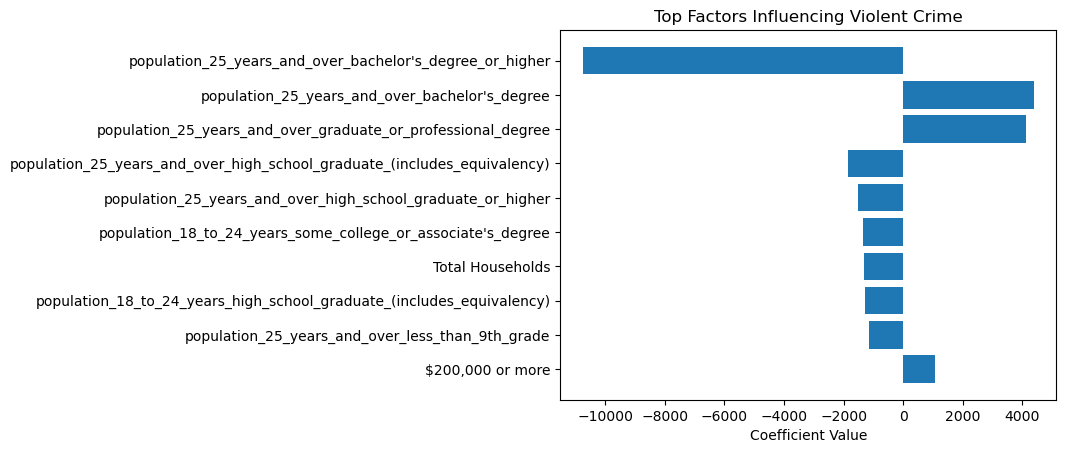

In [177]:
# View Coeffiecients by Feature
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coefficients.head(10))

# Plot Top Factors Influencing Violent Crime
top_features = coefficients.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Factors Influencing Violent Crime")
plt.xlabel("Coefficient Value")

plt.gca().invert_yaxis()
plt.savefig("../FIGURES/Figure_10")
plt.show()

### W/ PCA

Dimension Reduction Technique time: 0.0064 seconds


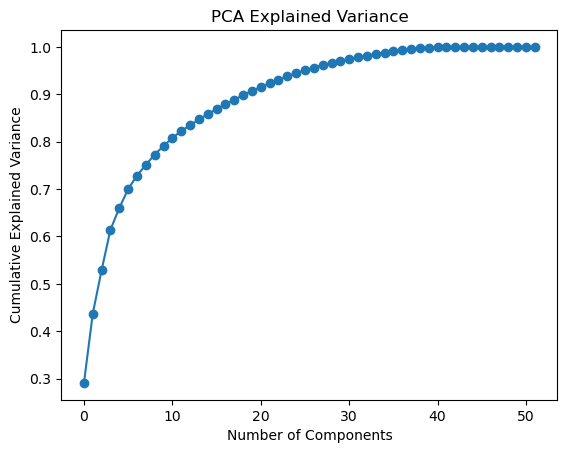

In [178]:
# Return PCA model and apply on x train and x test data
pca, X_train_std_pca, X_test_std_pca = dim_reduce("pca", X_train_std, X_test_std)

# Visualize the explained variance of each component
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.savefig("../FIGURES/Figure_11")
plt.show()

In [179]:
# According to the graph above, we can keep 10 components
pca, X_train_std_pca, X_test_std_pca = dim_reduce("pca", X_train_std, X_test_std, n_components = 10)

pca_df = pd.DataFrame(
    X_train_std_pca,
    columns=[f"PC{i+1}" for i in range(10)]
)

pca_df.head()

Dimension Reduction Technique time: 0.0027 seconds


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,4.361982,1.474949,-2.388725,-1.091518,-2.399492,1.066084,-0.055245,0.574053,-1.036563,-0.052425
1,6.238154,-0.617206,1.132804,4.564754,-1.847896,-0.669720,0.731178,0.151217,0.054690,-0.387378
2,4.163542,0.327613,-0.800046,-1.023330,0.787962,0.948580,-0.073030,-0.659135,-0.531234,0.278105
3,3.796443,0.064129,-0.734534,1.104603,1.553284,2.081780,-0.071104,0.660787,-0.047308,0.643940
4,0.771418,-0.066468,-2.800014,-0.913234,-0.677019,-0.127101,-0.193073,-0.696380,-2.687688,1.100133


In [180]:
# ReRun Linear Regression with PCA
lr = regression_model(reg_model,X_train_std_pca, X_test_std_pca, y_train, y_test)

Training time: 0.0041 seconds
Testing time: 0.0018 seconds
Mean Squared Error: 1012788.352
R² score: 0.28061131365914915


                                                         PC1       PC2  \
Less than $10,000                                  -0.113790 -0.046701   
$10,000 to $14,999                                 -0.147856 -0.034100   
$15,000 to $24,999                                 -0.179884  0.002646   
$25,000 to $34,999                                 -0.176157  0.007199   
$35,000 to $49,999                                 -0.170943  0.013473   
$50,000 to $74,999                                 -0.162824  0.030170   
$75,000 to $99,999                                 -0.077042  0.003046   
$100,000 to $149,999                                0.096185  0.022407   
$150,000 to $199,999                                0.187252  0.004989   
$200,000 or more                                    0.215425 -0.013269   
Total Households                                    0.094596 -0.124006   
population_18_to_24_years_bachelor's_degree_or_...  0.177250 -0.006105   
population_18_to_24_years_high_school_

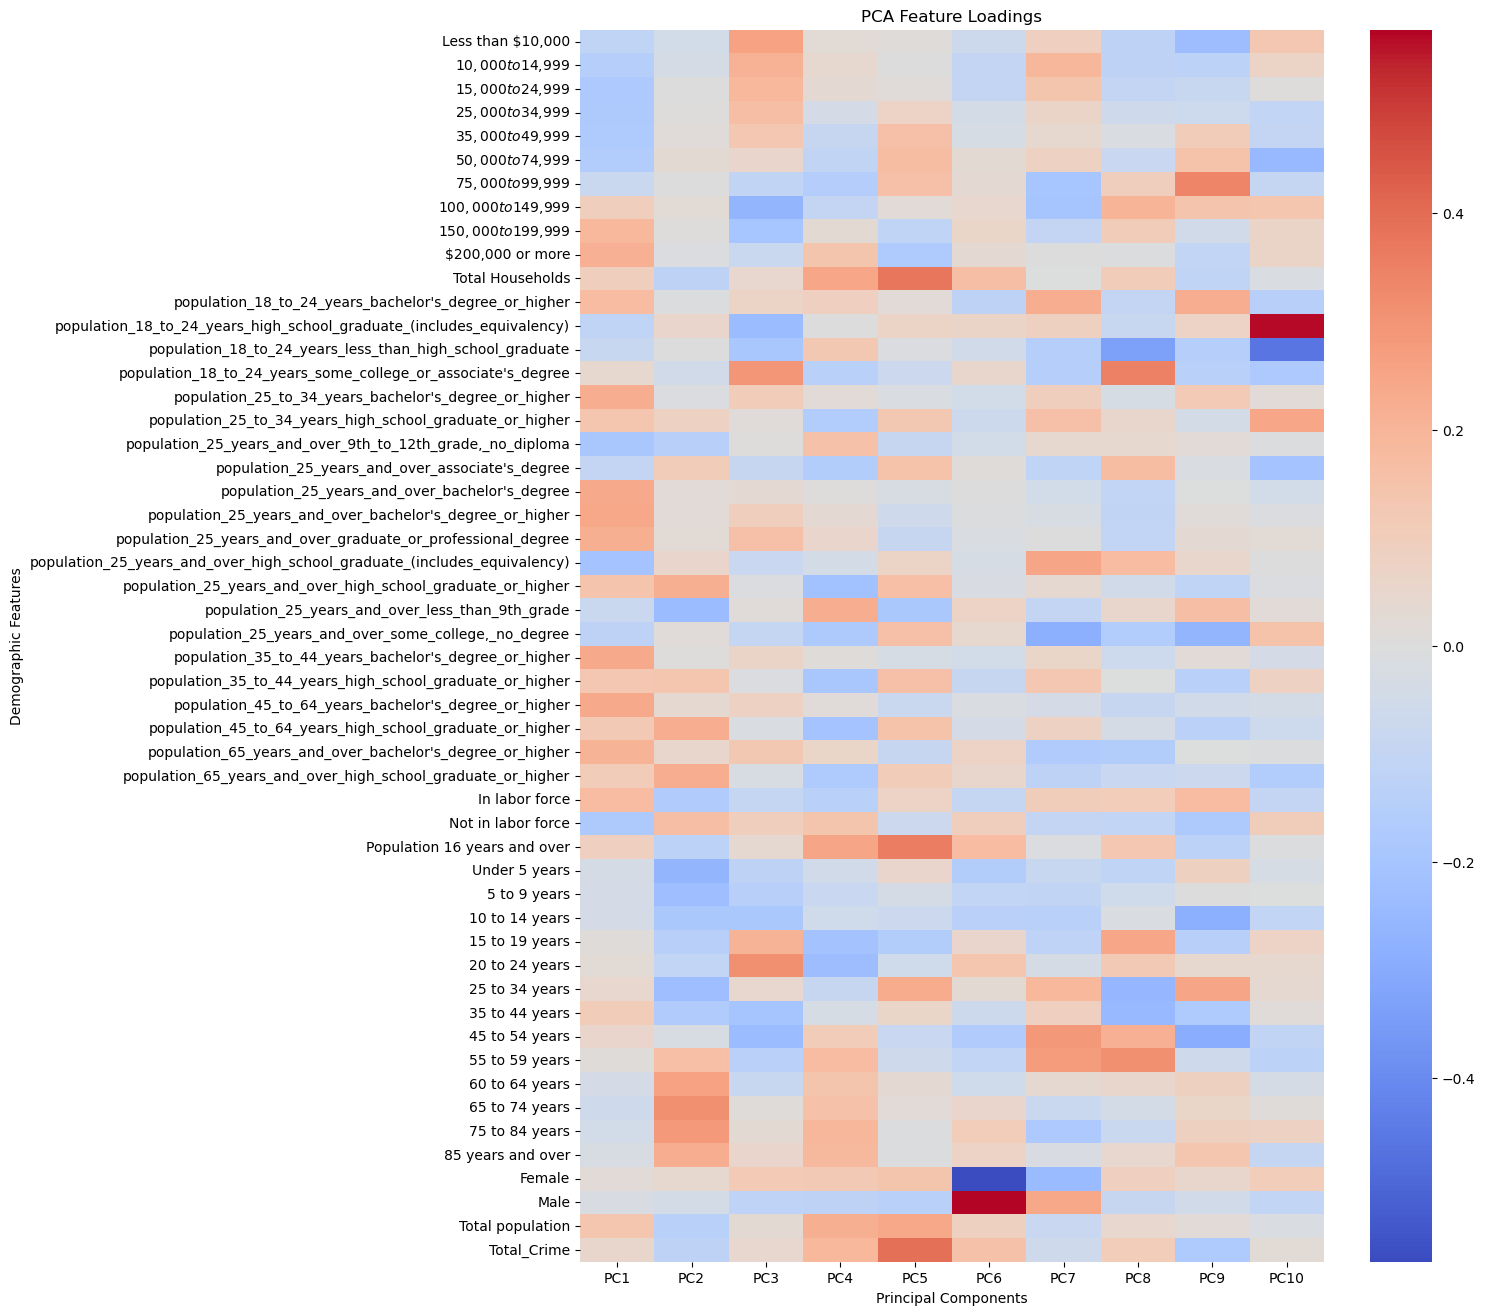

In [181]:
# VIEW PC by Feature
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(10)],
    index=X.columns
)

print(loadings)

# Plot into a HeatMap
plt.figure(figsize=(12,16))

sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Feature Loadings")
plt.xlabel("Principal Components")
plt.ylabel("Demographic Features")

plt.savefig("../FIGURES/Figure_12.jpg")
plt.show()

In [182]:
coefficients = pd.DataFrame({
    "Component": pca_df.columns,
    "Influence": lr.coef_
})

coefficients

,Component,Influence
0,PC1,-22.271958
1,PC2,-85.882329
2,PC3,92.691792
3,PC4,7.375731
4,PC5,162.458862
5,PC6,-30.604007
6,PC7,-92.354257
7,PC8,-195.019366
8,PC9,-70.860603
9,PC10,37.870159


Not much improvement with PCA. 

# Classification Models

## Logisitic Regresssion

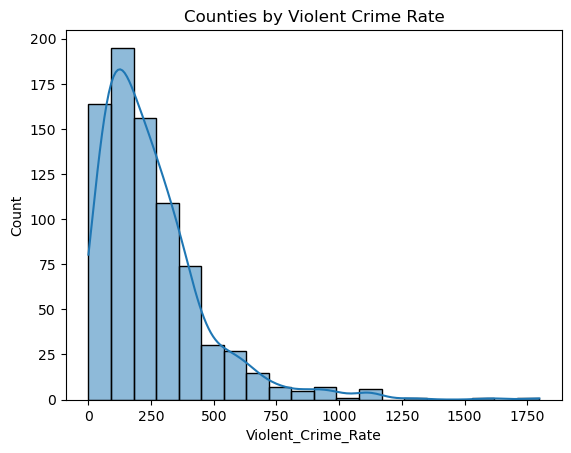

In [183]:
sns.histplot(crime_census_df["Violent_Crime_Rate"], bins=20, kde=True) # just the raw data
plt.title("Counties by Violent Crime Rate")  
plt.show()

In [188]:
# Create a copy 
df = crime_census_df.copy()

df["Total population"] = np.log(df["Total population"])

# Establish X and y
X = df.drop(columns=["county","state","Total Households","Population 16 years and over",
                            "latitude","longitude","Violent_Crimes_2024", "Property_Crimes_2024", "Violent_Crime_Rate","Property_Crime_Rate", "Total_Crime_Rate"])

# 
low_thresh = df["Total_Crime_Rate"].quantile(0.33)
high_thresh = df["Total_Crime_Rate"].quantile(0.67)

df["Total_Crime_Rate_Class"] = df["Total_Crime_Rate"].apply(
    lambda x: "low" if x <= low_thresh else ("high" if x >= high_thresh else "medium")
)
y = df["Total_Crime_Rate_Class"]

# Split data into testing and training
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.8,stratify=y,random_state=1)

# Standardize X_train X_test
X_train_std, X_test_std = standardize_data(X_train, X_test)

# Choose the model
class_model= "logistic regression"

# Without Dimension Reduction but with Feature Scaling, perform decision tree classification on dataset
log = classification_model(class_model,X_train_std, X_test_std, y_train, y_test,random_state=1, 
                     penalty='l2',        # regularization type
                     C=0.5,               # regularization strength
                     solver='lbfgs',  # optimizer
                     max_iter=200)       # iterations

Training time: 0.0471 seconds
Testing time: 0.0006 seconds
Misclassifed examples: 59 out of 160
Error: 0.369
Confusion_Matrix:
[[31  3 19]
 [ 3 37 13]
 [ 5 16 33]]
Accuracy: 0.631
Precision 0.654
Recall: 0.631
F1_score: 0.635


In [189]:
print(log.classes_)

['high' 'low' 'medium']


                                              Feature  Coefficient
49                                        Total_Crime     3.794597
48                                   Total population    -0.903021
28  population_45_to_64_years_high_school_graduate...     0.476319
29  population_65_years_and_over_bachelor's_degree...     0.445077
42                                     60 to 64 years    -0.388232
41                                     55 to 59 years    -0.364854
43                                     65 to 74 years     0.329700
22  population_25_years_and_over_high_school_gradu...    -0.272051
18     population_25_years_and_over_bachelor's_degree    -0.247204
16  population_25_years_and_over_9th_to_12th_grade...     0.223050


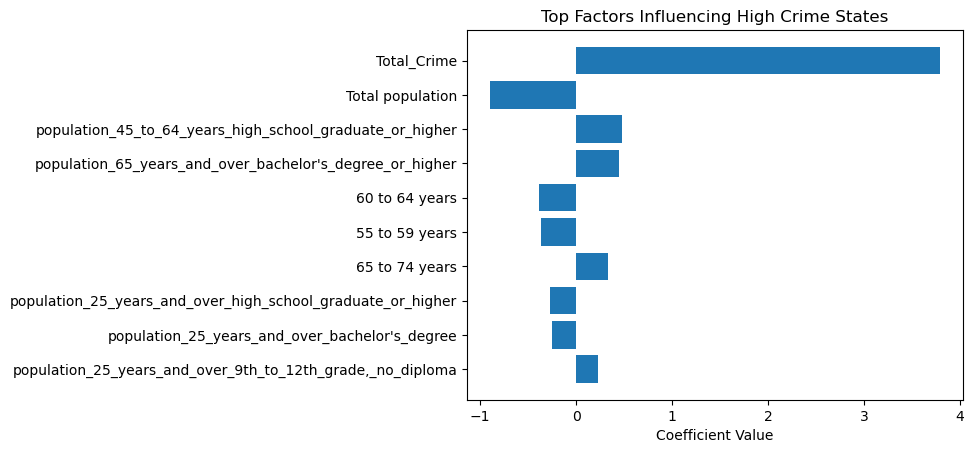

In [190]:
# View Coeffiecients by Feature
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coefficients.head(10))

# Plot Top Factors Influencing Violent Crime
top_features = coefficients.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Factors Influencing High Crime States")
plt.xlabel("Coefficient Value")

plt.gca().invert_yaxis()
plt.savefig("../FIGURES/Figure_13")
plt.show()

                                              Feature  Coefficient
49                                   Total_Crime_Rate    -2.189769
48                                        Total_Crime    -0.659298
23   population_25_years_and_over_less_than_9th_grade    -0.300011
24  population_25_years_and_over_some_college,_no_...    -0.292218
16  population_25_years_and_over_9th_to_12th_grade...     0.276893
35                                     10 to 14 years     0.262102
27  population_45_to_64_years_bachelor's_degree_or...     0.230859
42                                     60 to 64 years    -0.228170
14  population_25_to_34_years_bachelor's_degree_or...     0.219865
34                                       5 to 9 years     0.215263


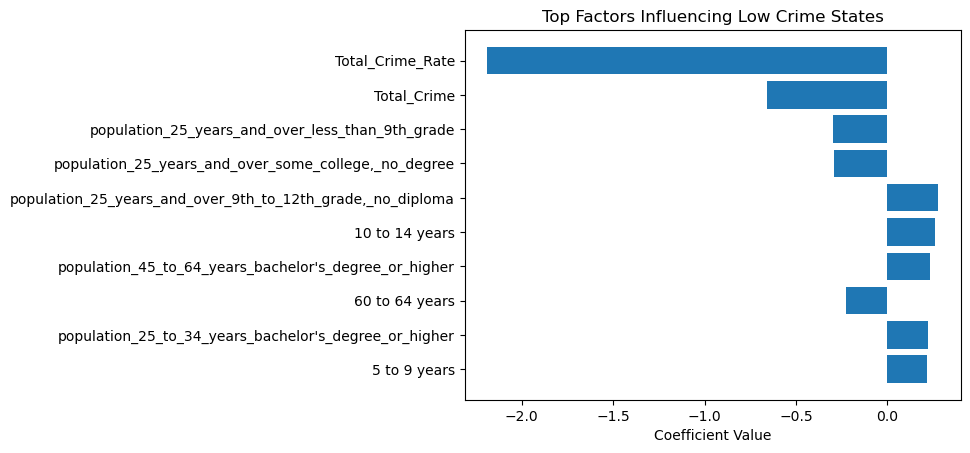

In [162]:
# View Coeffiecients by Feature
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log.coef_[1]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coefficients.head(10))

# Plot Top Factors Influencing Violent Crime
top_features = coefficients.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Factors Influencing Low Crime States")
plt.xlabel("Coefficient Value")

plt.gca().invert_yaxis()
plt.savefig("../FIGURES/Figure_14")
plt.show()

### W/ PCA

In [163]:
# Establish Dimension Reduction Technique
technique="pca"

# Call Dimension Reduction Technique
pca,X_train_std_pca, X_test_std_pca = dim_reduce(technique,X_train_std, X_test_std, y_train,n_components=10)

# Classify with Decision Tree, Feature Scaling, AND Dimension Reduction Technique
log_pca = classification_model(class_model,X_train_std_pca, X_test_std_pca, y_train, y_test,random_state=1, 
                     penalty='l2',        # regularization type
                     C=0.5,               # regularization strength
                     solver='lbfgs',  # optimizer
                     max_iter=200)

Dimension Reduction Technique time: 0.0068 seconds
Training time: 0.0108 seconds
Testing time: 0.0002 seconds
Misclassifed examples: 68 out of 160
Error: 0.425
Confusion_Matrix:
[[39  4 10]
 [ 8 31 14]
 [14 18 22]]
Accuracy: 0.575
Precision 0.567
Recall: 0.575
F1_score: 0.569


## NON Linear SVM

In [164]:
# Choose the model
class_model= "non linear svm"

# Without Dimension Reduction but with Feature Scaling, perform decision tree classification on dataset
nl_svm = classification_model(class_model,X_train_std, X_test_std, y_train, y_test,kernel="rbf", gamma=0.10, C=10.0, random_state=1)

Training time: 0.0497 seconds
Testing time: 0.0153 seconds
Misclassifed examples: 74 out of 160
Error: 0.463
Confusion_Matrix:
[[40  6  7]
 [10 24 19]
 [24  8 22]]
Accuracy: 0.537
Precision 0.543
Recall: 0.537
F1_score: 0.529


### W/ KPCA

In [165]:
# Establish Dimension Reduction Technique
technique="kpca"

# Call Dimension Reduction Technique
kpca, X_train_std_kpca, X_test_std_kpca = dim_reduce(technique,X_train_std, X_test_std, y_train,n_components=10, kernel='rbf', gamma=0.25)

# Classify with nonlinear svm, Feature Scaling, AND Dimension Reduction Technique
nl_svm_pca = classification_model(class_model,X_train_std, X_test_std, y_train, y_test,kernel="rbf", gamma=0.10, C=10.0, random_state=1)

Dimension Reduction Technique time: 0.0321 seconds
Training time: 0.0380 seconds
Testing time: 0.0140 seconds
Misclassifed examples: 74 out of 160
Error: 0.463
Confusion_Matrix:
[[40  6  7]
 [10 24 19]
 [24  8 22]]
Accuracy: 0.537
Precision 0.543
Recall: 0.537
F1_score: 0.529


## Decision Tree

In [166]:
# Choose the model
class_model= "decision tree"

# Without Dimension Reduction but with Feature Scaling, perform decision tree classification on dataset
dt = classification_model(class_model,X_train_std, X_test_std, y_train, y_test,criterion="gini", max_depth=10, random_state=1)

Training time: 0.0215 seconds
Testing time: 0.0008 seconds
Misclassifed examples: 61 out of 160
Error: 0.381
Confusion_Matrix:
[[36  5 12]
 [ 4 40  9]
 [11 20 23]]
Accuracy: 0.619
Precision 0.614
Recall: 0.619
F1_score: 0.612


## KNN

In [167]:
# Choose the model
class_model= "knn"

# Without Dimension Reduction but with Feature Scaling, perform decision tree classification on dataset
knn = classification_model(class_model,X_train_std, X_test_std, y_train, y_test,n_neighbors=7,metric="euclidean")


Training time: 0.0019 seconds
Testing time: 0.0075 seconds
Misclassifed examples: 70 out of 160
Error: 0.438
Confusion_Matrix:
[[37  6 10]
 [ 8 27 18]
 [14 14 26]]
Accuracy: 0.562
Precision 0.561
Recall: 0.562
F1_score: 0.560


# FIGURES

In [168]:
import plotly.express as px
import pandas as p


fig = px.scatter_mapbox(
    crime_census_df,
    lat="latitude",
    lon="longitude",
    size="Violent_Crime_Rate",
    color="Violent_Crime_Rate",
    hover_name="county",
    hover_data=["county", "Violent_Crime_Rate"],
    color_continuous_scale="Viridis",
    size_max=40,
    zoom=3
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0,"t":0,"l":0,"b":0}
)

plt.savefig("../FIGURES/Figure_15.jpg")

fig.show()

C:\Users\laura\AppData\Local\Temp\ipykernel_6188\1449559580.py:5: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



<Figure size 640x480 with 0 Axes>